In [57]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.image import imread
from tqdm.notebook import tqdm
import numpy as np
import torch
from collections import Counter
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
import time

plt.rcParams['font.family'] = 'AppleGothic'
mpl.rcParams['font.family'] = 'AppleGothic'
classes = os.listdir('./data/data')
classes


['input_69_2_7.jpg',
 'input_11_7_12.jpg',
 'input_81_4_10.jpg',
 'input_84_6_1.jpg',
 'input_36_3_3.jpg',
 'input_38_7_15.jpg',
 'input_3_1_15.jpg',
 'input_75_2_13.jpg',
 'input_17_8_2.jpg',
 'input_61_4_7.jpg',
 'input_95_4_6.jpg',
 'input_5_10_6.jpg',
 'input_97_6_13.jpg',
 'input_27_1_4.jpg',
 'input_91_10_9.jpg',
 'input_48_9_6.jpg',
 'input_2_1_15.jpg',
 'input_74_2_13.jpg',
 'input_26_3_3.jpg',
 'input_39_7_15.jpg',
 'input_79_2_7.jpg',
 'input_10_7_12.jpg',
 'input_94_6_1.jpg',
 'input_80_4_10.jpg',
 'input_96_6_13.jpg',
 'input_58_9_6.jpg',
 'input_90_10_9.jpg',
 'input_37_1_4.jpg',
 'input_4_10_6.jpg',
 'input_71_4_7.jpg',
 'input_85_4_6.jpg',
 'input_5_5_14.jpg',
 'input_73_6_12.jpg',
 'input_47_4_5.jpg',
 'input_33_5_8.jpg',
 'input_75_10_8.jpg',
 'input_17_3_13.jpg',
 'input_18_5_1.jpg',
 'input_39_9_10.jpg',
 'input_56_6_2.jpg',
 'input_91_2_12.jpg',
 'input_10_3_1.jpg',
 'input_65_4_11.jpg',
 'input_6_1_1.jpg',
 'input_16_3_13.jpg',
 'input_11_1_6.jpg',
 'input_7_3_6.jp

In [58]:
labels = pd.read_csv('./chinese_mnist.csv')
labels

,suite_id,sample_id,code,value,character
0,1,1,10,9,九
1,1,10,10,9,九
2,1,2,10,9,九
3,1,3,10,9,九
4,1,4,10,9,九
...,...,...,...,...,...
14995,99,5,9,8,八
14996,99,6,9,8,八
14997,99,7,9,8,八
14998,99,8,9,8,八


In [59]:
a=labels['suite_id'].unique()#봉사자 고유인원
a.sort()
print(a ,len(a))

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100] 100


In [60]:
b=labels['sample_id'].unique()#봉사자가 15개의 한자를 10번적음
b.sort()
print(b ,len(b))

[ 1  2  3  4  5  6  7  8  9 10] 10


In [61]:
c=labels['character'].unique()#한자
print(c ,len(c))

['九' '十' '百' '千' '万' '亿' '零' '一' '二' '三' '四' '五' '六' '七' '八'] 15


In [62]:
d=labels['value'].unique()#한자의 뜻
d.sort()
print(d ,len(d))

[        0         1         2         3         4         5         6
         7         8         9        10       100      1000     10000
 100000000] 15


In [63]:
e=labels['code'].unique()#한자 인덱스? 한자0 = 1, 한자10000 = 14
e.sort()
print(e ,len(e))

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15] 15


In [64]:
# 데이터프레임에 파일 컬럼 추가하고 값입력
def cfn(x):
    file_name = f"input_{x[0]}_{x[1]}_{x[2]}.jpg"
    return file_name

labels['file'] = labels.apply(cfn,axis = 1)
labels

,suite_id,sample_id,code,value,character,file
0,1,1,10,9,九,input_1_1_10.jpg
1,1,10,10,9,九,input_1_10_10.jpg
2,1,2,10,9,九,input_1_2_10.jpg
3,1,3,10,9,九,input_1_3_10.jpg
4,1,4,10,9,九,input_1_4_10.jpg
...,...,...,...,...,...,...
14995,99,5,9,8,八,input_99_5_9.jpg
14996,99,6,9,8,八,input_99_6_9.jpg
14997,99,7,9,8,八,input_99_7_9.jpg
14998,99,8,9,8,八,input_99_8_9.jpg


In [65]:
labels.groupby(['value','character']).size()# 개수확인

value      character
0          零            1000
1          一            1000
2          二            1000
3          三            1000
4          四            1000
5          五            1000
6          六            1000
7          七            1000
8          八            1000
9          九            1000
10         十            1000
100        百            1000
1000       千            1000
10000      万            1000
100000000  亿            1000
dtype: int64

In [66]:
labels.isnull().sum()#NaN개수 확인

suite_id     0
sample_id    0
code         0
value        0
character    0
file         0
dtype: int64

In [67]:
#데이터세트 만들고 
dataset = []
image_path = './data/data'

for i in tqdm(range(len(labels))):
    codei = labels.loc[i,'code']
    filei = labels.loc[i,'file']
    path = os.path.join(image_path,filei)
    path_img = imread(path)
    image = path_img.astype(np.float32)
    image2 = torch.from_numpy(image)
    dataset += [[image2, codei-1]]

  0%|          | 0/15000 [00:00<?, ?it/s]

In [68]:
# 64x64 pixel
img, l = dataset[10000]
print(img.shape)
print(l)

torch.Size([64, 64])
4


<Figure size 648x648 with 0 Axes>

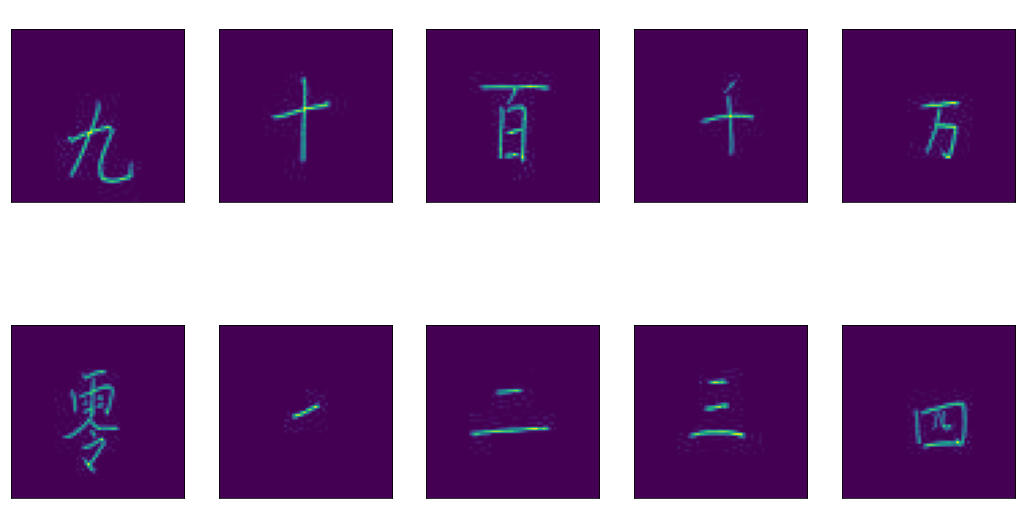

In [69]:
fig = plt.figure(figsize=(9,9))
target_label = ['零', '一', '二', '三', '四', '五', '六', '七', '八', '九', '十', '百', '千', '万', '亿']
font = {'family' : 'AppleGothic', 'size':20}

fig = plt.figure(figsize=(18, 10))
for i in range(10):
    image, label = dataset[i*1200]
    ax = fig.add_subplot(2, 5, i+1, xticks=[], yticks = [])
    ax.imshow(image.numpy().astype(int))
    ax.set_title(target_label[label], color='white', fontdict=font);

In [70]:
dataset

[[tensor([[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]),
  9],
 [tensor([[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]),
  9],
 [tensor([[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]),
  9],
 [tensor([[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0

In [71]:
#랜덤으로 train, val값에 데이터를 나누어 넣음
from sklearn.model_selection import train_test_split

idx_label = {}

for i in range(len(dataset)):
    _, label = dataset[i]
    idx_label[i] = label
x_train, x_val, y_train, y_val = train_test_split(list(idx_label.keys()), list(idx_label.values()), 
                                                  stratify = list(idx_label.values()), test_size=0.05)

idx_label_2 = {}
for idx, label in idx_label.items():
    if idx not in x_val:
        idx_label_2[idx] = label

#split data train and test after exlude x_val
x_train, x_test, y_train, y_test = train_test_split(list(idx_label_2.keys()), list(idx_label_2.values()),
                                                    stratify = list(idx_label_2.values()), test_size=0.05)


print(len(x_train))
print(len(x_val))
print(len(x_test))

13537
750
713


In [72]:
def plot_dist(indexes, dataset=dataset):
    #dist = {}
    count = Counter()
    for i in indexes:
        _, label = dataset[i]
        count[target_label[label]] += 1
        
    dist_2 = dict(sorted(count.items(), key=lambda kv: kv[1], reverse=True))
    plt.bar(dist_2.keys(), dist_2.values())
    plt.title('Data distribution')
    plt.ylabel('count')
    plt.show()

/opt/homebrew/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20159 (\N{CJK UNIFIED IDEOGRAPH-4EBF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


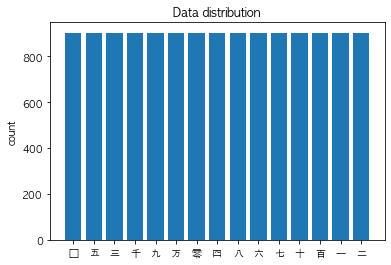

/opt/homebrew/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20159 (\N{CJK UNIFIED IDEOGRAPH-4EBF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


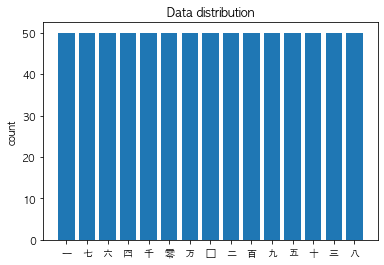

/opt/homebrew/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20159 (\N{CJK UNIFIED IDEOGRAPH-4EBF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


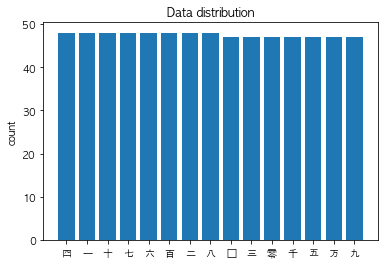

In [73]:
plot_dist(x_train)
plot_dist(x_val)
plot_dist(x_test)

In [74]:
from torch.utils.data import DataLoader, SubsetRandomSampler
    
train_set = SubsetRandomSampler(x_train)
val_set = SubsetRandomSampler(x_val)
test_set = SubsetRandomSampler(x_test)

batchsize= 16

train_loader = DataLoader(dataset, batch_size=batchsize, 
                          num_workers=4, sampler= train_set)
val_loader = DataLoader(dataset, batch_size=batchsize,  
                        num_workers=4, sampler=val_set)
test_loader = DataLoader(dataset, batch_size = batchsize,
                          num_workers=4, sampler=test_set)

In [75]:
for images, _ in train_loader:
    print(images.shape)
    print(images.size)

torch.Size([16, 64, 64])
<built-in method size of Tensor object at 0x2d30bdf40>
torch.Size([16, 64, 64])
<built-in method size of Tensor object at 0x17eb34450>
torch.Size([16, 64, 64])
<built-in method size of Tensor object at 0x2d30bdcc0>
torch.Size([16, 64, 64])
<built-in method size of Tensor object at 0x17eb34ae0>
torch.Size([16, 64, 64])
<built-in method size of Tensor object at 0x17eb34400>
torch.Size([16, 64, 64])
<built-in method size of Tensor object at 0x17eb34b80>
torch.Size([16, 64, 64])
<built-in method size of Tensor object at 0x17eb34900>
torch.Size([16, 64, 64])
<built-in method size of Tensor object at 0x17eb34720>
torch.Size([16, 64, 64])
<built-in method size of Tensor object at 0x17eb34090>
torch.Size([16, 64, 64])
<built-in method size of Tensor object at 0x17eb34220>
torch.Size([16, 64, 64])
<built-in method size of Tensor object at 0x17eb34a40>
torch.Size([16, 64, 64])
<built-in method size of Tensor object at 0x17eb34400>
torch.Size([16, 64, 64])
<built-in metho

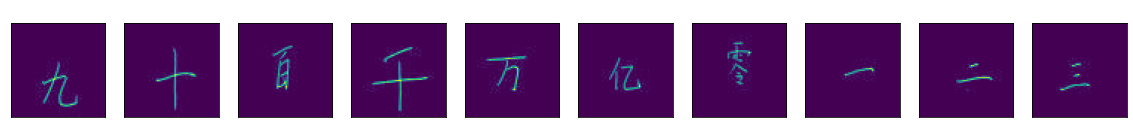

In [76]:
fig = plt.figure(figsize=(20, 2))
for i in range(10):
    image, label = dataset[i*1100]
    ax = fig.add_subplot(1, 10, i+1, xticks=[], yticks = [])
    ax.imshow(image)
    ax.set_title(target_label[label], color='white');

In [77]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [80]:
model = nn.Conv2d
model = models.resnet18(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 15)


model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

In [81]:
import torchsummary
print(model)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [82]:
num_features

512

In [83]:
num_epochs = 1
start_time = time.time()

train_all_acc = []
train_all_loss = []
val_all_acc = []
val_all_loss = []

# 전체 반복(epoch) 수 만큼 반복하며
for epoch in range(num_epochs):

    print('Epoch:', str(epoch+1) + '/' + str(num_epochs))
    print('-'*10)

    for phase in ['train', 'val']:

        running_loss = 0.
        running_corrects = 0
        
        if phase == 'train':

            model.train()

            for inputs, labels in train_loader:

                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()
                outputs = model(inputs)

                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                loss.backward()
                optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / int(len(x_train))
            epoch_acc = running_corrects / int(len(x_train)) * 100.

            print(phase,'|' , ' Loss: {:.6f}  / Train Acc: {:.6f}%'.format(epoch_loss,epoch_acc))

            train_all_loss.append(epoch_loss)
            train_all_acc.append(epoch_acc)

        if phase == 'val':

            model.eval()

            for inputs, labels in val_loader:

                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / int(len(x_val))
            epoch_acc = running_corrects / int(len(x_val)) * 100.

            print(phase ,'|', ' Loss: {:.6f}  / Acc: {:.6f}%'.format(epoch_loss,epoch_acc))

            val_all_loss.append(epoch_loss)
            val_all_acc.append(epoch_acc)

    print('Time:'+ str(int(time.time() - start_time)//60)+'분'+str(int(time.time() - start_time)%60)+'초')



Epoch: 1/1
----------


RuntimeError: Given groups=1, weight of size [64, 3, 7, 7], expected input[1, 16, 64, 64] to have 3 channels, but got 16 channels instead

In [28]:
torch.save(model, 'resnet.pt')

In [69]:
def showtime(input, title):
    # torch.Tensor를 numpy 객체로 변환
    input = input.numpy().astype(int)
    # 이미지 출력
    plt.imshow(input)
    plt.title(title)
    plt.show()

In [70]:
from PIL import Image

model = torch.load('resnet.pt')
model.eval()
start_time = time.time()

with torch.no_grad():
    running_loss = 0.
    running_corrects = 0

    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

        # 한 배치의 첫 번째 이미지에 대하여 결과 시각화
        print(f'[예측 결과: {target_label[preds[0]]}] (실제 정답: {target_label[labels.data[0]]})')
        showtime(inputs.cpu().data[0])

    epoch_loss = running_loss / len(test_set)
    epoch_acc = running_corrects / len(test_set) * 100.
    print('[Test Phase] Loss: {:.4f} Acc: {:.4f}% Time: {:.4f}s'.format(epoch_loss, epoch_acc, time.time() - start_time))

RuntimeError: Given groups=1, weight of size [64, 64, 3, 3], expected input[1, 32, 64, 64] to have 64 channels, but got 32 channels instead